# Linear maps

In [173]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [174]:
def plot_vectors(v, axes):
    for i in range(len(v)):
        axes[0].quiver(0, 0, 0, v[i,0], v[i,1], v[i,2], linewidth=2, label=f'v{i+1}')
    return axes

def config_r3(axes, title, min = -1, max = 1):
    axes[0].set_title(title)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_zlabel('Z')
    axes[0].set_xlim(min, max)
    axes[0].set_ylim(min, max)
    axes[0].set_zlim(min, max)
    axes[0].legend()
    return axes 

def plot_span(axes, v, min = -1, max = 1, step = 0.2):
    dim = len(v)
    steps = np.arange(min, max + step, step).tolist()
    coeffs = list(product(steps, repeat=dim))
    span = []
    for a in coeffs:
        # Coeficientes en columna (dim,1) para que a[i]*v[i] multiplique fila a fila; (dim,1)*(dim,3)->(dim,3)
        vec = (np.array(a).reshape(-1, 1) * v).sum(axis=0)
        span.append(vec)
    span = np.unique(np.array(span), axis=0)
    axes[0].scatter(span[:, 0], span[:, 1], span[:, 2], c='b', marker='o', label="Span de v", alpha=0.1)
    return axes

In [175]:
def draw_grid(ax, T=None):
    grid_range = range(-10, 11)
    
    for x in grid_range:
        pts = np.array([[x, -10], [x, 10]])
        if T is not None:
            pts = (T @ pts.T).T
        ax.plot(pts[:,0], pts[:,1], linewidth=0.5, color = "black")
        
    for y in grid_range:
        pts = np.array([[-10, y], [10, y]])
        if T is not None:
            pts = (T @ pts.T).T
        ax.plot(pts[:,0], pts[:,1], linewidth=0.5, color = "black")

def draw_grid_3d(ax, basis, lim=6, step=2):
    """Dibuja la cuadrícula del plano (o espacio) transformado. basis: (2,3) o (3,3) con vectores fila."""
    basis = np.asarray(basis)
    if basis.shape[0] == 2:
        b1, b2 = basis[0], basis[1]
        for k in range(-lim, lim + 1, step):
            start, end = k*b2 - lim*b1, k*b2 + lim*b1
            ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 'k-', linewidth=0.5, alpha=0.7)
        for k in range(-lim, lim + 1, step):
            start, end = k*b1 - lim*b2, k*b1 + lim*b2
            ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 'k-', linewidth=0.5, alpha=0.7)
    else:
        b1, b2, b3 = basis[0], basis[1], basis[2]
        for i in range(-lim, lim + 1, step):
            for j in range(-lim, lim + 1, step):
                start, end = i*b2 + j*b3 - lim*b1, i*b2 + j*b3 + lim*b1
                ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 'k-', linewidth=0.5, alpha=0.6)
        for i in range(-lim, lim + 1, step):
            for j in range(-lim, lim + 1, step):
                start, end = i*b1 + j*b3 - lim*b2, i*b1 + j*b3 + lim*b2
                ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 'k-', linewidth=0.5, alpha=0.6)
        for i in range(-lim, lim + 1, step):
            for j in range(-lim, lim + 1, step):
                start, end = i*b1 + j*b2 - lim*b3, i*b1 + j*b2 + lim*b3
                ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 'k-', linewidth=0.5, alpha=0.6)

A linear map from V to W is a function T: V -> W

Goes from one vector space to another.

For example:

$T(x, y, z) = (x + 0.5y + 0.2, 0.2x + 0.1y + 0.3z)$

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_20024\2345745751.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


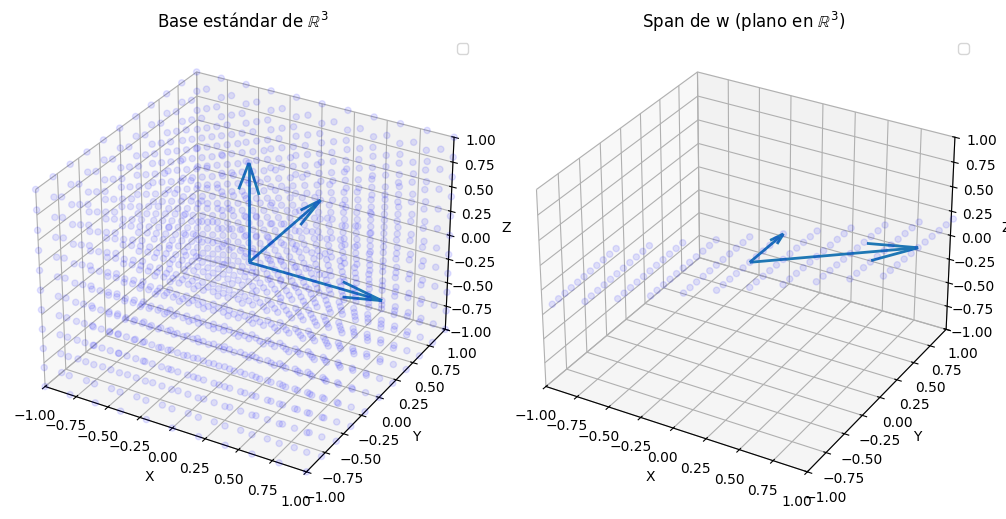

In [176]:
v = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]])
# This matrix represents the linear map
w = np.array([
    [1, 0.5, 0.2],
    [0.2, 0.1, 0.3]])
    
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axes = [fig.add_subplot(1, 2, i+1, projection='3d') for i in range(2)]
config_r3([axes[0]], 'Base estándar de $\mathbb{R}^3$')
plot_span([axes[0]], v)
plot_vectors(v, [axes[0]])

config_r3([axes[1]], 'Span de w (plano en $\mathbb{R}^3$)')
plot_span([axes[1]], w)
plot_vectors(w, [axes[1]])
plt.show()

Note that linear maps, always maps $0_v$ to $0_w$

## Kernel and Range

*Kernel* or null space is the set of vectors that maps to the origin of the new space, given a linear map $T$

$null\ T = { v \in V: Tv = 0}$

$T$ is *injective* if and only if $null\ T = {0}$

*Range* is the subset of $W$ consisting of those vectors that are equal to $Tv$ for some $v \in V$:

$range\ T = {Tv: v \in V}$

$T$ is *surjective* if its range equals $W$

If is *injective* and *surjective* is *bijective*

A linear map to a lower-dimensional space is not injective

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_20024\2345745751.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


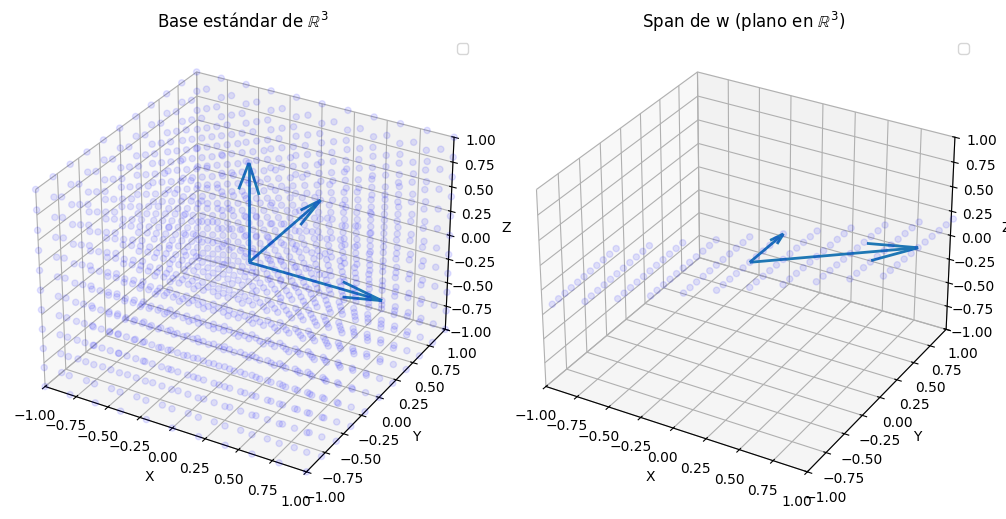

In [177]:
v = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]])
# This matrix represents the linear map
w = np.array([
    [1, 0.5, 0.2],
    [0.2, 0.1, 0.3]])
    
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axes = [fig.add_subplot(1, 2, i+1, projection='3d') for i in range(2)]
config_r3([axes[0]], 'Base estándar de $\mathbb{R}^3$')
plot_span([axes[0]], v)
plot_vectors(v, [axes[0]])

config_r3([axes[1]], 'Span de w (plano en $\mathbb{R}^3$)')
plot_span([axes[1]], w)
plot_vectors(w, [axes[1]])
plt.show()

A linear map to an upper-dimension is not surjective

## Matrices as linear maps

In [178]:
def plot_transform(T, v = None, space_name = "T"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)

    axes[0].set_title("Original space")
    axes[0].set_xlim(-6,6)
    axes[0].set_ylim(-6,6)
    axes[0].set_aspect('equal')

    draw_grid(axes[0])

    axes[0].arrow(0,0,1,0,head_width=0.1,head_length=0.1,color="b", label="$e_1$")
    axes[0].arrow(0,0,0,1,head_width=0.1,head_length=0.1,color="g", label="$e_2$")
    if v is not None:
        Tv = T@v
        axes[0].arrow(0,0,v[0],v[1], head_width=0.2, head_length=0.2, color="r", label="$v$")
    axes[0].legend()

    axes[1].set_title(space_name)
    axes[1].set_xlim(-6,6)
    axes[1].set_ylim(-6,6)
    axes[1].set_aspect('equal')

    draw_grid(axes[1], T=T)

    if v is not None:
        axes[1].arrow(0,0,Tv[0],Tv[1], head_width=0.2, head_length=0.2, color="r",label="$Tv$")
    axes[1].arrow(0,0,T[0,0],T[1,0], head_width=0.1, head_length=0.1, color="b", label="$f_1$")
    axes[1].arrow(0,0,T[0,1],T[1,1], head_width=0.1, head_length=0.1, color="g", label="$f_2$")
    axes[1].legend()
    return axes

We can use a matrix designed to perform a rotation in the space

[]

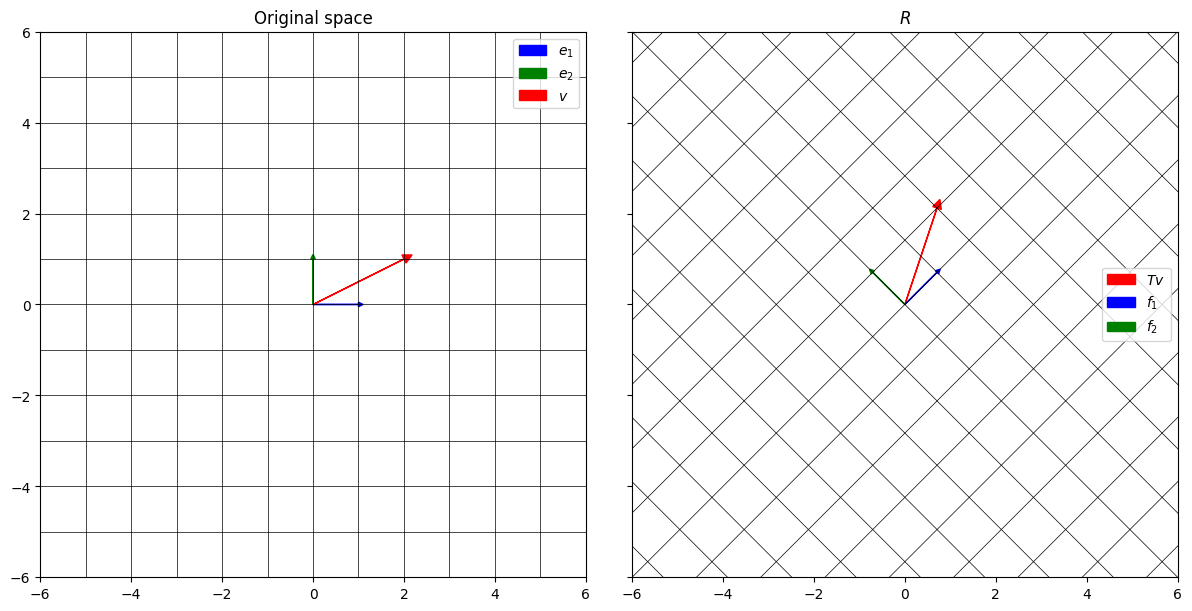

In [179]:
angle = np.pi * 1/4 #radians
R = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle),  np.cos(angle)]
])

v = np.array([2, 1])
axes = plot_transform(R, v, space_name="$R$")
plt.plot()

A scale

[]

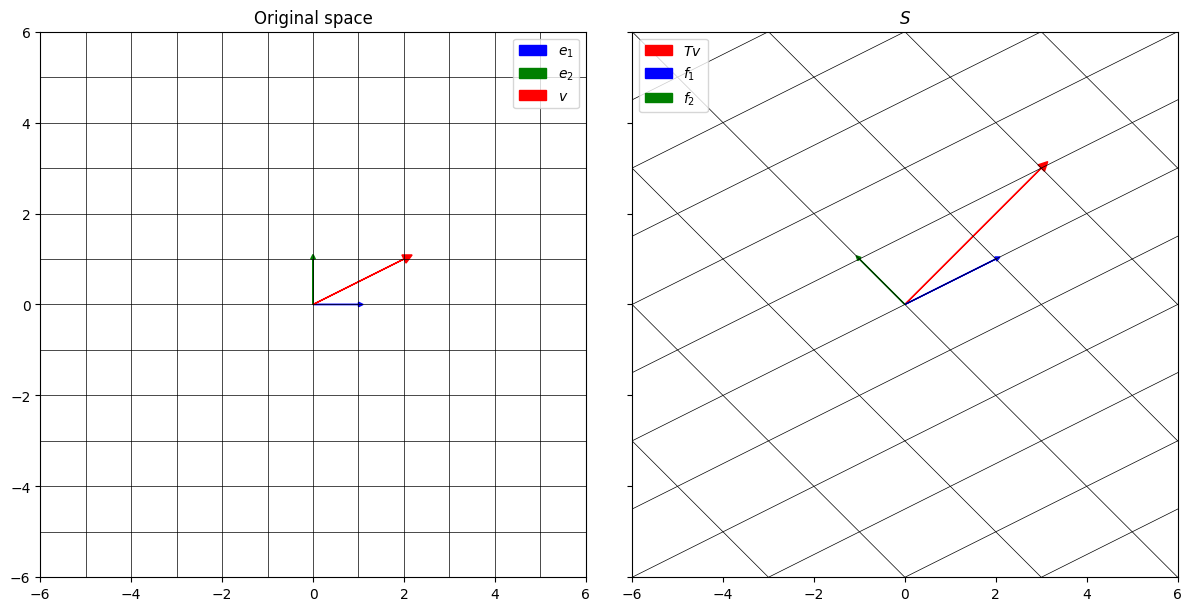

In [180]:

S = np.array([
    [2, -1],
    [1, 1]
])
axes = plot_transform(S, v, space_name="$S$")
plt.plot()

We can compose linear maps via matrix multiplication

[]

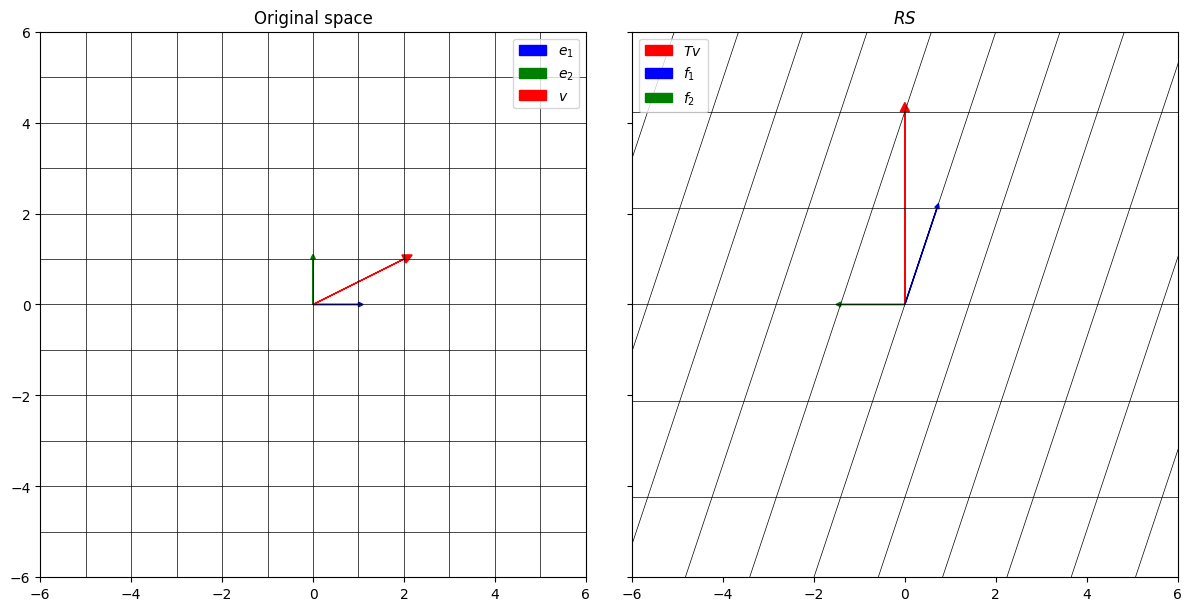

In [181]:
T = R @ S  # Composition of linear maps
axes = plot_transform(T, v, space_name="$RS$")
plt.plot()

We can visually check that matrix multiplication is not conmutative

$SR \ne RS$

[]

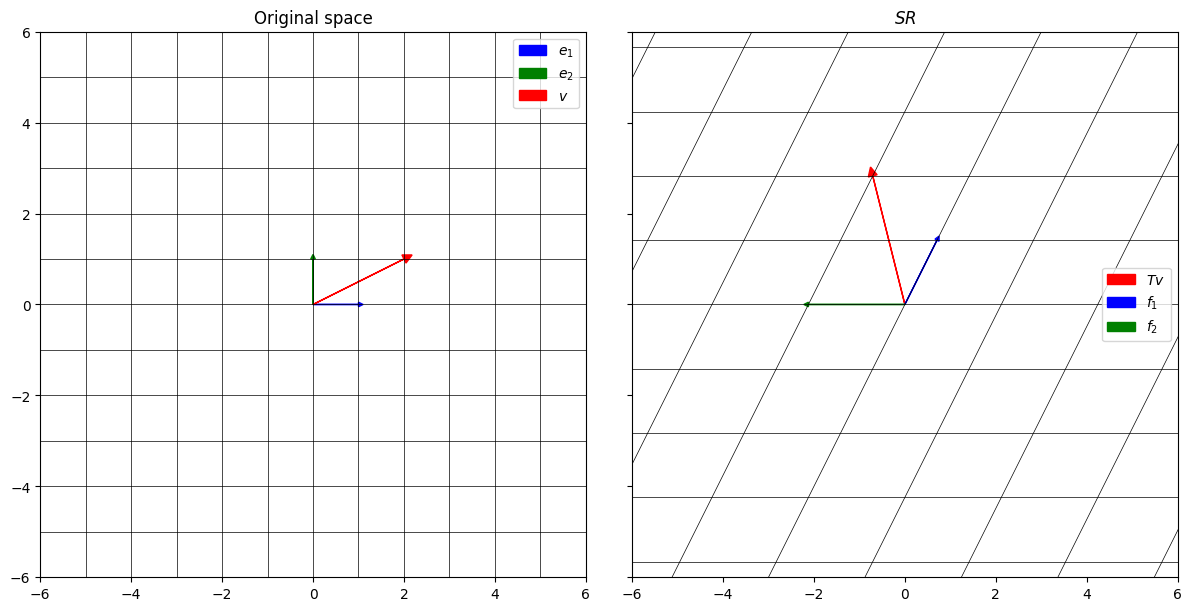

In [182]:
T = S @ R  # Composition of linear maps
axes = plot_transform(T, v, space_name="$SR$")
plt.plot()

## Determinant

Is the factor by which is scaled the n-dimensional volume.

In SR matrix, the absolute value of the determinant is 3

In [183]:
display(T)
det = np.linalg.det(T)
abs_det = np.abs(det)
abs_det

array([[ 0.70710678, -2.12132034],
       [ 1.41421356,  0.        ]])

np.float64(3.000000000000001)

This means that our volume is scaled by 3 in the new space

[]

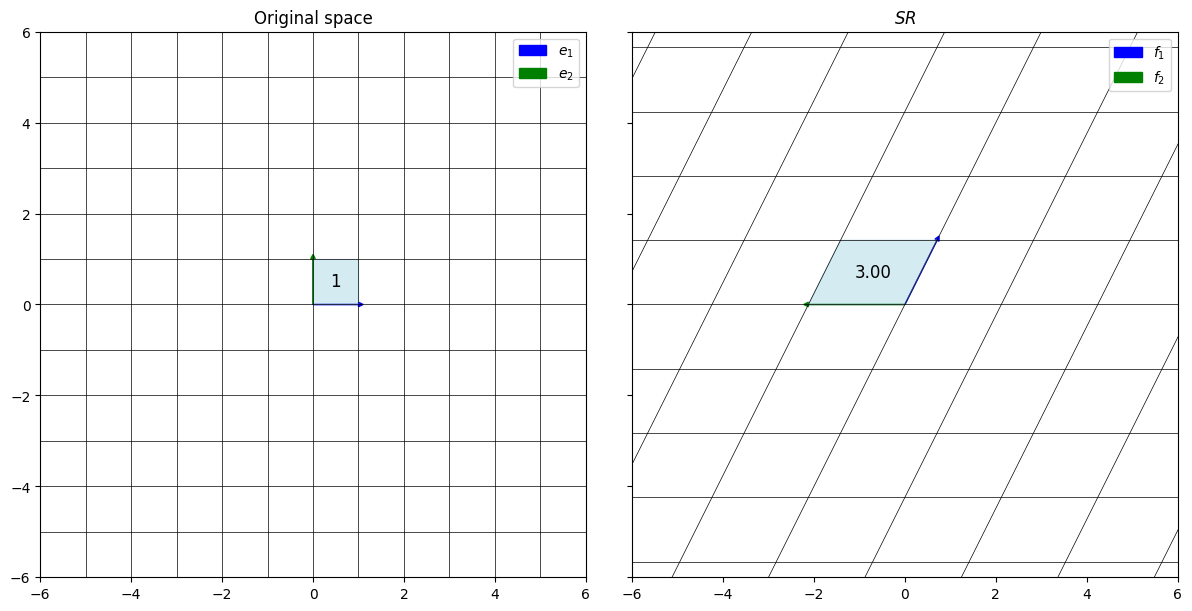

In [184]:
axes = plot_transform(T, space_name="$SR$")
square_vertices = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
pos_text = square_vertices[2]/2

axes[0].fill(square_vertices[:,0], square_vertices[:,1], color='lightblue', alpha=0.5)
axes[0].text(pos_text[0], pos_text[1], '1', ha='center', va='center', fontsize=12, color='black')

square_vertices_transformed = T @ square_vertices.T
pos_text = square_vertices_transformed[:,2]/2
axes[1].fill(square_vertices_transformed[0], square_vertices_transformed[1], color='lightblue', alpha=0.5)
axes[1].text(pos_text[0], pos_text[1], f'{abs_det:.2f}', ha='center', va='center', fontsize=12, color='black')

plt.plot()

What if we use a matrix that is Linearly dependent? 

Well, the determinant is 0, this means that the n-dim volume will be compressed to zero in a lower dimension (1D in this case)

In [185]:
U = np.array([
    [1, 1],
    [1, 1]
])
display(U)
det = np.linalg.det(U)
abs_det = np.abs(det)
abs_det

array([[1, 1],
       [1, 1]])

np.float64(0.0)

[]

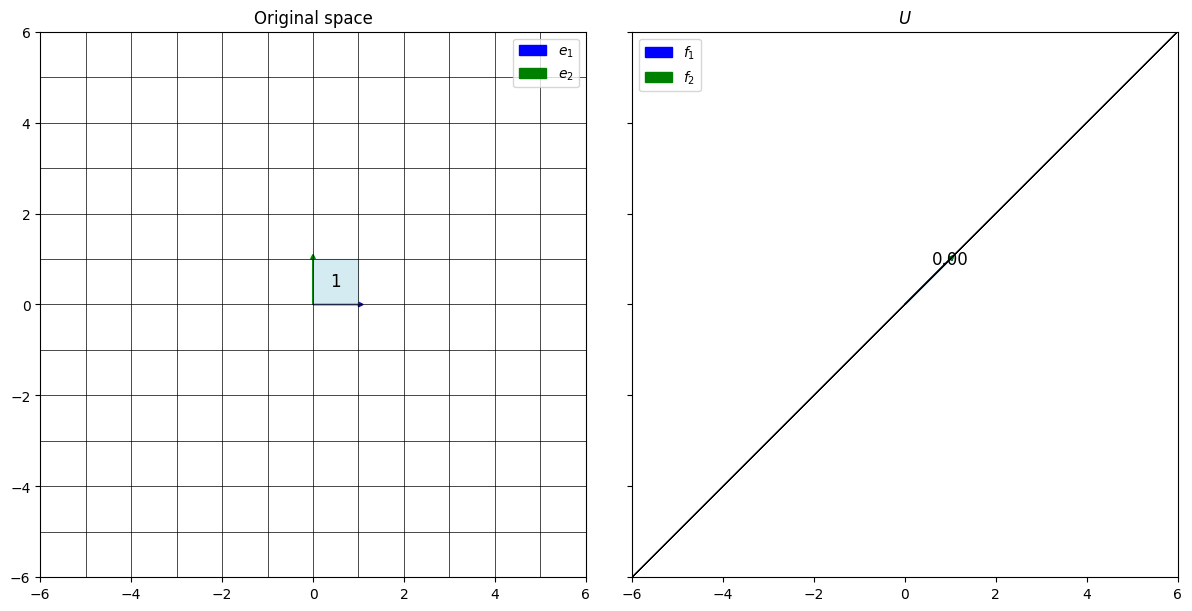

In [186]:
axes = plot_transform(U, space_name="$U$")
square_vertices = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
pos_text = square_vertices[2]/2

axes[0].fill(square_vertices[:,0], square_vertices[:,1], color='lightblue', alpha=0.5)
axes[0].text(pos_text[0], pos_text[1], '1', ha='center', va='center', fontsize=12, color='black')

square_vertices_transformed = U @ square_vertices.T
pos_text = square_vertices_transformed[:,2]/2
axes[1].fill(square_vertices_transformed[0], square_vertices_transformed[1], color='lightblue', alpha=0.5)
axes[1].text(pos_text[0], pos_text[1], f'{abs_det:.2f}', ha='center', va='center', fontsize=12, color='black')

plt.plot()

## Inverses

An inverse of a matrix, is another matrix, which multiplied, it gives the identity

In [187]:
T = S@R
T

array([[ 0.70710678, -2.12132034],
       [ 1.41421356,  0.        ]])

In [188]:
T_inv = np.linalg.inv(T)
T_inv

array([[ 0.        ,  0.70710678],
       [-0.47140452,  0.23570226]])

In [189]:
(T_inv@T).round(2)

array([[ 1.,  0.],
       [-0.,  1.]])

In [190]:
(T@T_inv).round(2)

array([[1., 0.],
       [0., 1.]])

If the determinant is different to zero, the linear map can be invertible! this means, we can go back to the original space

This will be our vector transformed by SR

In [191]:
Tv = T@v
Tv

array([-0.70710678,  2.82842712])

We will invert SR

In [192]:
T_inv = np.linalg.inv(T)
T_inv

array([[ 0.        ,  0.70710678],
       [-0.47140452,  0.23570226]])

And if we use it, it maps to the original vector (2, 1)

In [193]:
T_inv@Tv

array([2., 1.])

## Basis change

We can use the inverse to apply a basis change.

We keep the vector to evaluate in the same place, but only transforms the space.

Which are the coordinates of our vector using the new bases? 

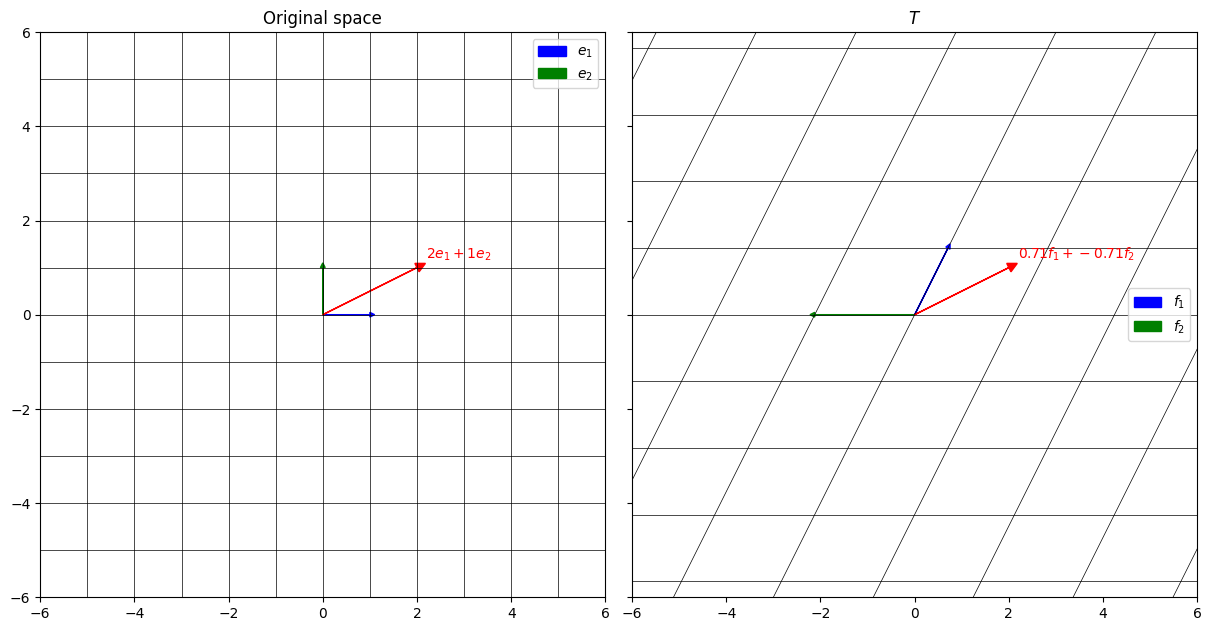

In [194]:
v = [2, 1]
axes = plot_transform(T, space_name="$T$")
axes[0].arrow(0, 0, v[0], v[1], head_length = 0.2, head_width = 0.2, color="r")
axes[0].text(v[0] + 0.2, v[1] + 0.2, f"${v[0]}e_1 + {v[1]}e_2$", color="r")

vf = T_inv@v

axes[1].arrow(0, 0, v[0], v[1], head_length = 0.2, head_width = 0.2, color="r")
text = f"${round(vf[0], 2)}f_1 + {round(vf[1], 2)}f_2$"
axes[1].text(v[0] + 0.2, v[1] + 0.2, text, color="r")
plt.show()

$T$ maps $v$ to the new space $W$.

$T^{-1}$ maps $v_w$ back to $V$

Now let's expand this to a linear map (matrix) instead of a vector.

A is a linear mapping $V \rightarrow W$

With respect to the standard bases $B$ and $C$

array([[ 1,  2],
       [ 3, -1]])

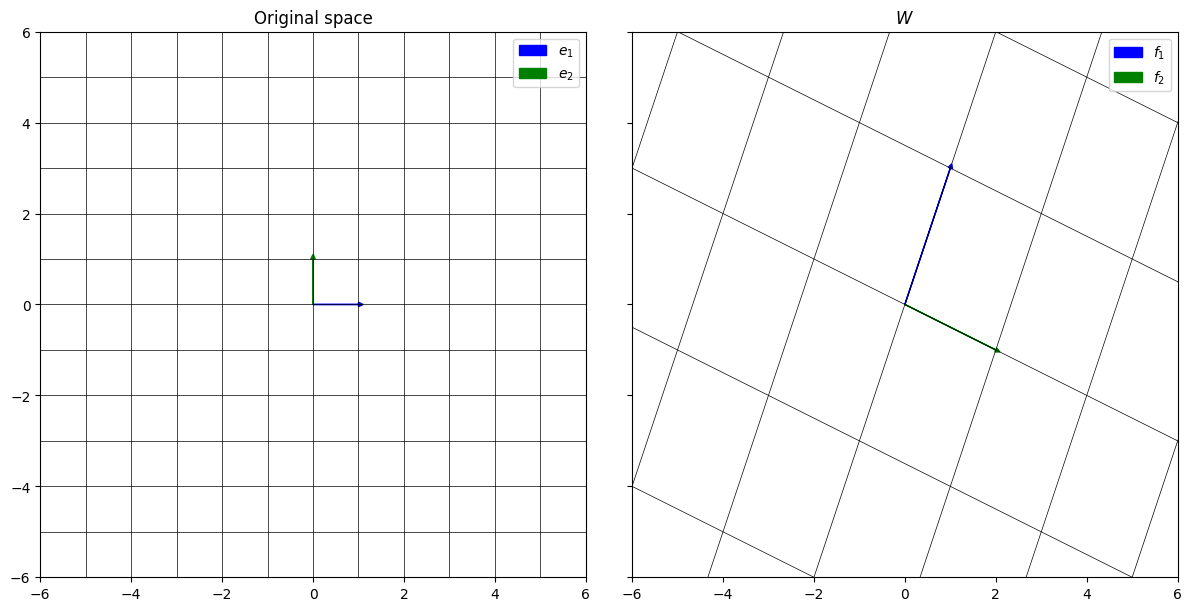

In [199]:
A = np.array([
    [1, 2],
    [3, -1]
])
display(A)
axes = plot_transform(A, space_name="$W$")

Now, we seek the transformation matriz with respect to the new bases $\~B$ and $\~C$.

S will be the coordinate representation of $\~B$ with respect to B. 

T will be the coordinate representation of $\~C$ with respect to C.

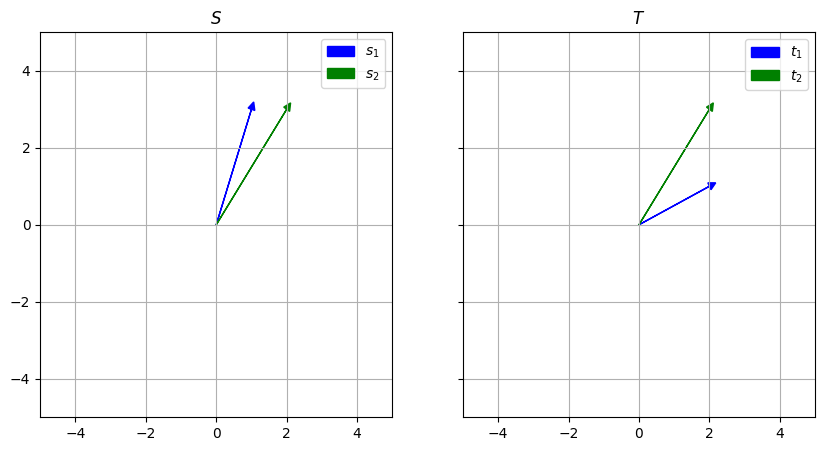

In [202]:
S = np.array([
    [1, 3],
    [2, 3]
]).T
T = np.array([
    [2, 1],
    [2, 3]
]).T

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex = True, sharey = True )
axes[0].grid(True)
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(-5, 5)
axes[0].set_title("$S$")
axes[0].arrow(0, 0, S[0, 0], S[1, 0], head_length = 0.2, head_width = 0.2, label="$s_1$", color="b")
axes[0].arrow(0, 0, S[0, 1], S[1, 1], head_length = 0.2, head_width = 0.2, label="$s_2$", color="g")
axes[0].legend()


axes[1].set_title("$T$")
axes[1].grid(True)
axes[1].set_xlim(-5, 5)
axes[1].set_ylim(-5, 5)

axes[1].arrow(0, 0, T[0, 0], T[1, 0], head_length = 0.2, head_width = 0.2, label="$t_1$", color="b")
axes[1].arrow(0, 0, T[0, 1], T[1, 1], head_length = 0.2, head_width = 0.2, label="$t_2$", color="g")
axes[1].legend()
plt.show()

$A: B \rightarrow C$

$S: \~B \rightarrow B$

$T: \~C \rightarrow C$

$\~A: \~B \rightarrow \~C$

How do we obtain $\~A$ ? 

We can take a long path: 

$\~A: \~B \rightarrow \~C$

$\~A: \~B \rightarrow B \rightarrow C \rightarrow \~C$

$\~A = T^{-1}AS$

In [203]:
A_changed = np.linalg.inv(T)@A@S
A_changed

array([[ 5.25,  4.5 ],
       [-1.75, -0.5 ]])

This is our new linear mapping using the new basis

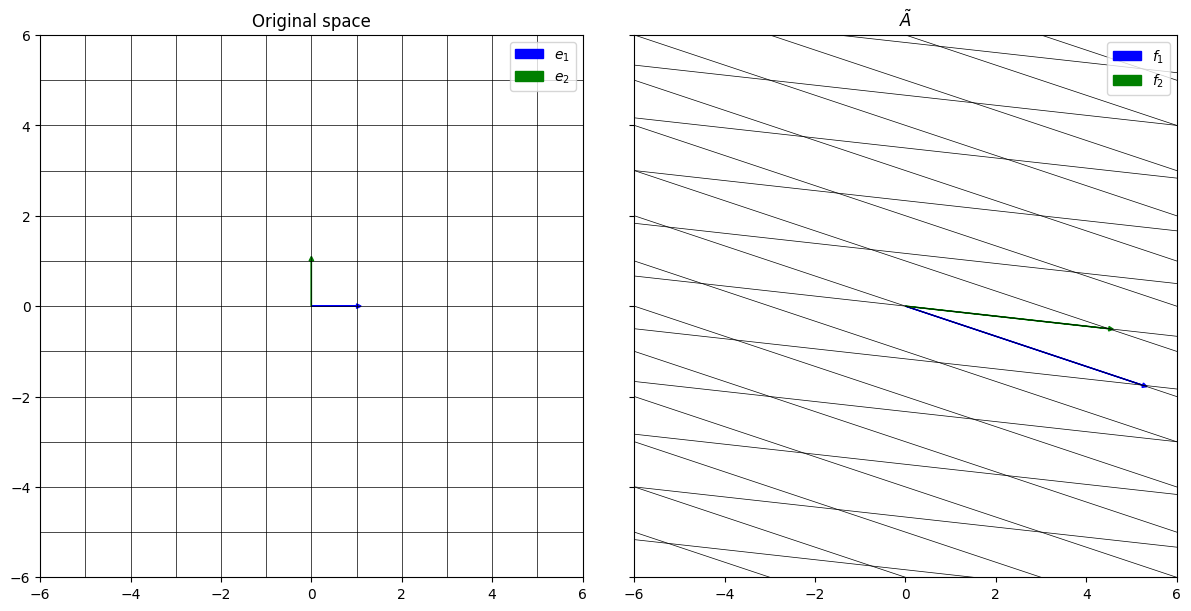

In [204]:
axes = plot_transform(A_changed, space_name="$\~A$")